Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 720 non-null    object 
 1   Apprehended_CBP      720 non-null    float64
 2   CBP_Custody          720 non-null    float64
 3   Transferred_Out_CBP  720 non-null    float64
 4   HHS_Care             720 non-null    object 
 5   Discharged_HHS       720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


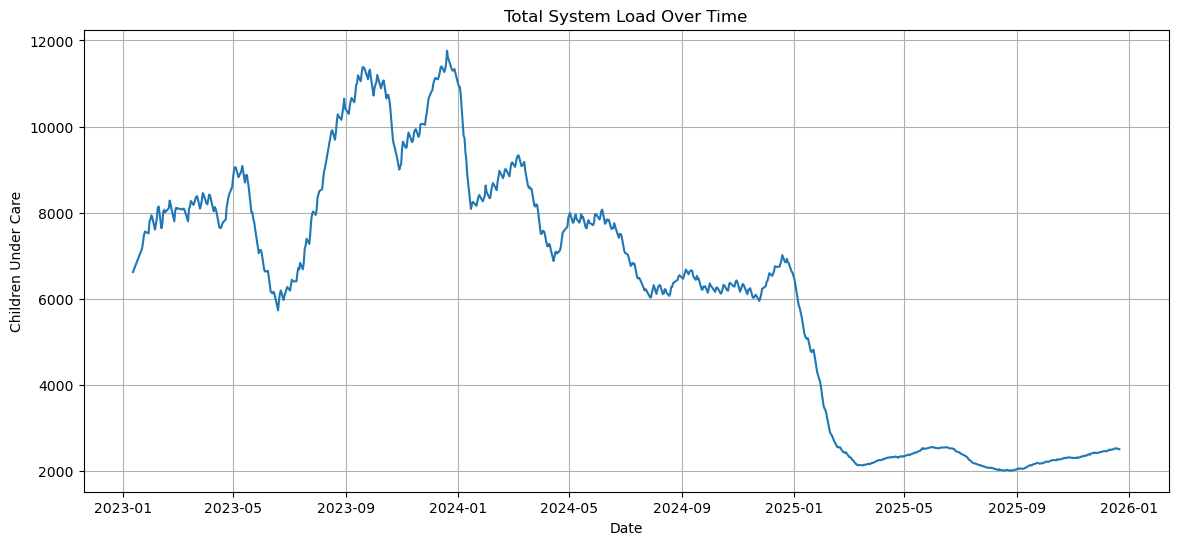

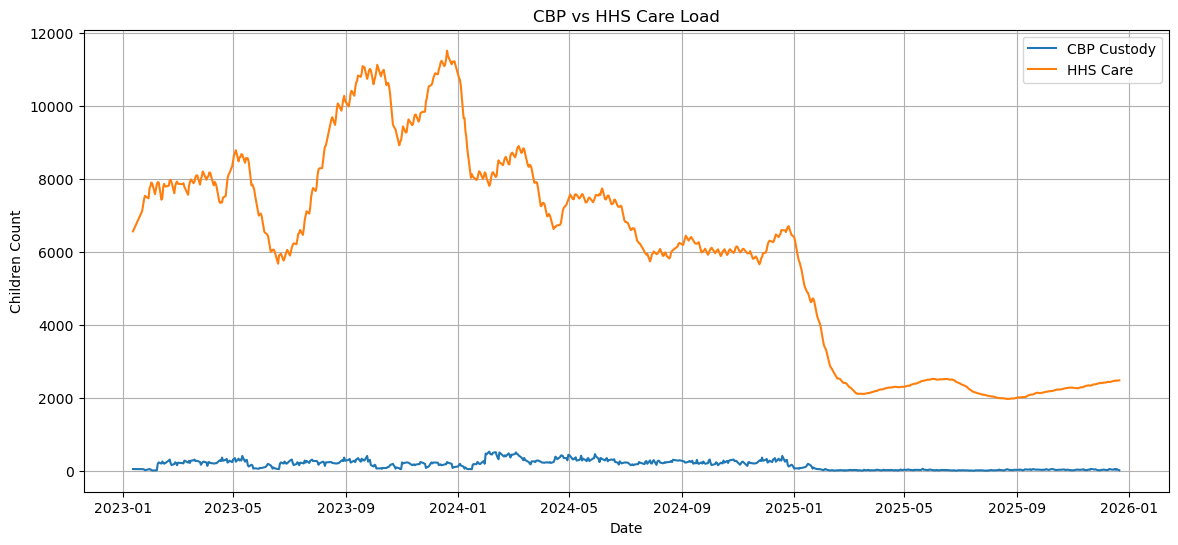

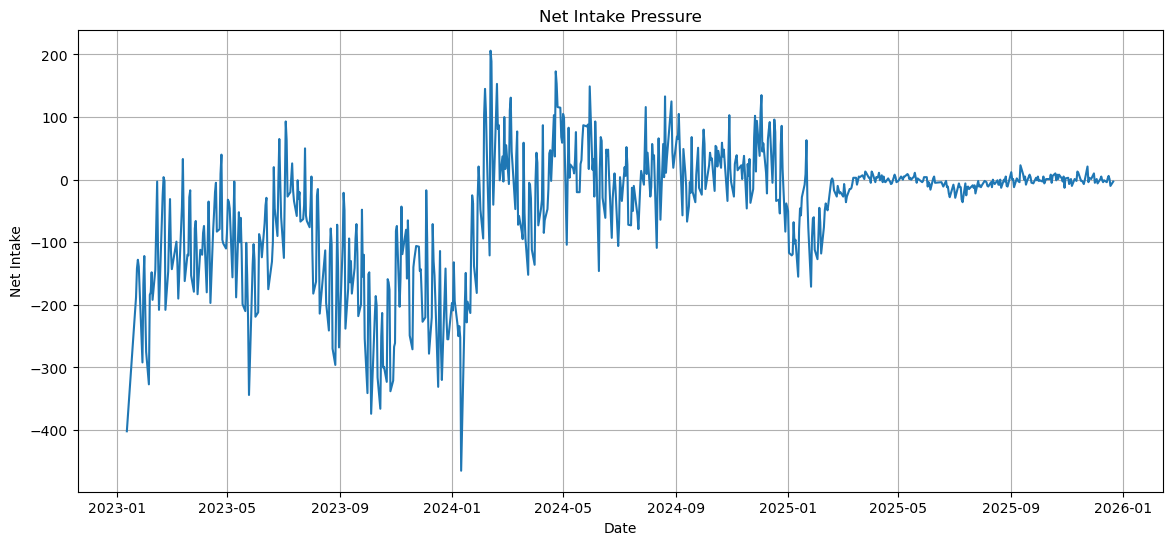

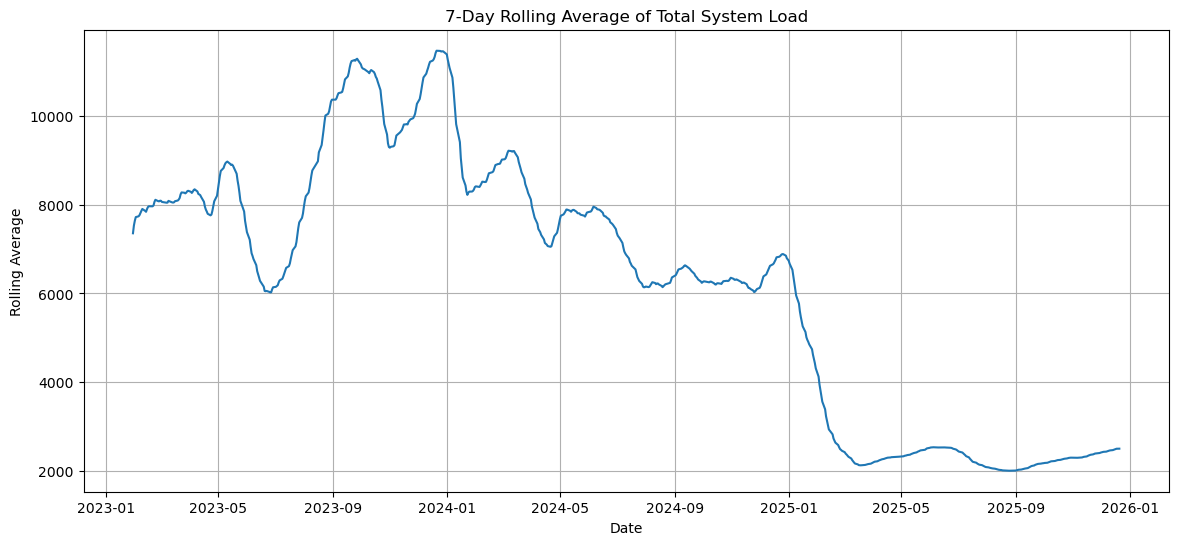

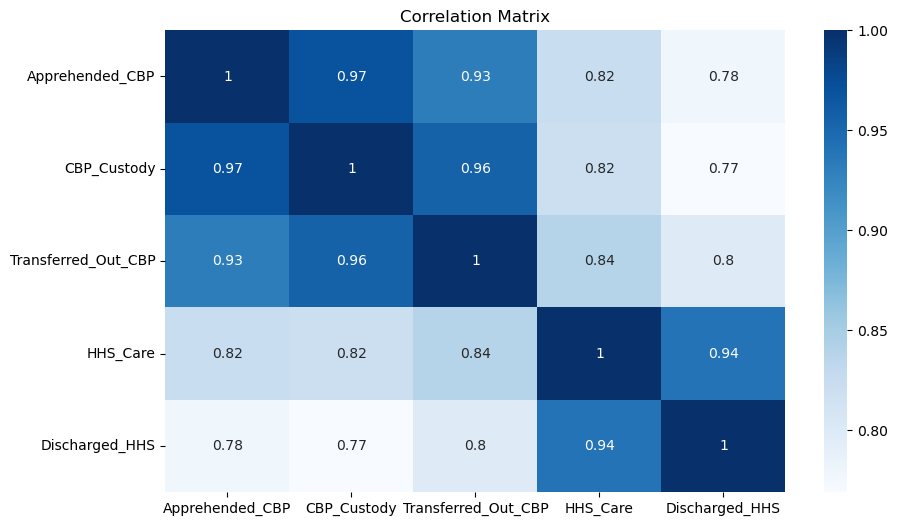


KEY OBSERVATIONS

1. HHS Care consistently contributes the highest proportion of total care load.

2. Periods of elevated Net Intake indicate temporary operational pressure.

3. Rolling averages reveal sustained high-load intervals across the system.

4. Growth rate fluctuations indicate variability in care demand.

5. System load trends after early 2025 suggest operational stabilization or reduced intake surges.

Cleaned dataset exported successfully.


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET

df = pd.read_csv("../data/uac_data.csv")


# DISPLAY FIRST 5 ROWS

df.head()

# COLUMN NAMES

print(df.columns)

# CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Children apprehended and placed in CBP custody*': 'Apprehended_CBP',
    'Children in CBP custody': 'CBP_Custody',
    'Children transferred out of CBP custody': 'Transferred_Out_CBP',
    'Children in HHS Care': 'HHS_Care',
    'Children discharged from HHS Care': 'Discharged_HHS'
})

# ---------------------------------------------------------
# DATASET INFORMATION
# ---------------------------------------------------------

df.info()

# ---------------------------------------------------------
# CHECK MISSING VALUES
# ---------------------------------------------------------

df.isnull().sum()

# ---------------------------------------------------------
# CONVERT DATE COLUMN
# ---------------------------------------------------------

df['Date'] = pd.to_datetime(df['Date'])

# ---------------------------------------------------------
# CLEAN NUMERIC COLUMNS
# ---------------------------------------------------------

numeric_cols = [
    'Apprehended_CBP',
    'CBP_Custody',
    'Transferred_Out_CBP',
    'HHS_Care',
    'Discharged_HHS'
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

    df[col] = df[col].fillna(0)

    df[col] = df[col].astype(int)

# ---------------------------------------------------------
# SORT DATA
# ---------------------------------------------------------

df = df.sort_values('Date')

df = df.reset_index(drop=True)

# ---------------------------------------------------------
# CREATE DERIVED METRICS
# ---------------------------------------------------------

# Total System Load

df['Total_System_Load'] = (
    df['CBP_Custody'] +
    df['HHS_Care']
)

# Net Intake Pressure

df['Net_Intake'] = (
    df['Transferred_Out_CBP'] -
    df['Discharged_HHS']
)

# Growth Rate

df['Growth_Rate'] = (
    df['Total_System_Load']
    .pct_change() * 100
)

# Rolling Average

df['Rolling_7_Day'] = (
    df['Total_System_Load']
    .rolling(7)
    .mean()
)

# ---------------------------------------------------------
# DESCRIPTIVE STATISTICS
# ---------------------------------------------------------

df.describe()

# ---------------------------------------------------------
# TOTAL SYSTEM LOAD TREND
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Total_System_Load']
)

plt.title("Total System Load Over Time")

plt.xlabel("Date")

plt.ylabel("Children Under Care")

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# CBP VS HHS CARE LOAD
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['CBP_Custody'],
    label='CBP Custody'
)

plt.plot(
    df['Date'],
    df['HHS_Care'],
    label='HHS Care'
)

plt.title("CBP vs HHS Care Load")

plt.xlabel("Date")

plt.ylabel("Children Count")

plt.legend()

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# NET INTAKE PRESSURE
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Net_Intake']
)

plt.title("Net Intake Pressure")

plt.xlabel("Date")

plt.ylabel("Net Intake")

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# ROLLING AVERAGE ANALYSIS
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Rolling_7_Day']
)

plt.title("7-Day Rolling Average of Total System Load")

plt.xlabel("Date")

plt.ylabel("Rolling Average")

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# CORRELATION MATRIX
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")

plt.show()

# ---------------------------------------------------------
# KEY OBSERVATIONS
# ---------------------------------------------------------

print("""
KEY OBSERVATIONS

1. HHS Care consistently contributes the highest proportion of total care load.

2. Periods of elevated Net Intake indicate temporary operational pressure.

3. Rolling averages reveal sustained high-load intervals across the system.

4. Growth rate fluctuations indicate variability in care demand.

5. System load trends after early 2025 suggest operational stabilization or reduced intake surges.
""")

# ---------------------------------------------------------
# EXPORT CLEANED DATASET
# ---------------------------------------------------------

df.to_csv(
    "../exports/cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset exported successfully.")